In [30]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

sigma = 0.564  # ≈ pi/6 (noise strength)
N_list = np.linspace(20, 200, 10, dtype=int)

BATCH_SIZE    = 4
LR_DEFAULT    = 1e-3
N_EPOCHS_FC   = 400
N_EPOCHS_CNN  = 400
OUTPUT_DIM    = 32  # 16 Re + 16 Im of rho; later can switch to 16 tau params


In [31]:
def proj(ket: np.ndarray) -> np.ndarray:
    return ket @ ket.conj().T

def build_projector_matrix() -> np.ndarray:
    """Build the 6x6 matrix P of two-qubit projectors as in Lohani."""
    H = np.array([[1.0], [0.0]], dtype=complex)
    V = np.array([[0.0], [1.0]], dtype=complex)

    D = (H + V) / np.sqrt(2)
    A = (H - V) / np.sqrt(2)
    R = (H + 1j * V) / np.sqrt(2)
    L = (H - 1j * V) / np.sqrt(2)

    h = proj(H)
    v = proj(V)
    d = proj(D)
    a = proj(A)
    r = proj(R)
    l = proj(L)

    projs = [h, v, d, a, r, l]
    P = np.empty((6, 6), dtype=object)
    for i in range(6):
        for j in range(6):
            P[i, j] = np.kron(projs[i], projs[j])
    return P

P = build_projector_matrix()


In [32]:
def random_mixed_state() -> np.ndarray:
    """Generate a random 4x4 mixed state using the Ginibre ensemble."""
    G = (np.random.normal(size=(4, 4))
         + 1j * np.random.normal(size=(4, 4)))
    rho = G @ G.conj().T
    rho /= np.trace(rho)
    return rho


In [33]:
def noisy_unitary(sigma: float) -> np.ndarray:
    """Random SU(2) unitary from Gaussian-distributed Euler angles."""
    theta, phi, zeta = np.random.normal(0, sigma, 3)
    U = np.array([
        [np.exp(1j * phi / 2) * np.cos(theta),      -1j * np.exp(1j * zeta) * np.sin(theta)],
        [-1j * np.exp(-1j * zeta) * np.sin(theta),   np.exp(-1j * phi / 2) * np.cos(theta)]
    ], dtype=complex)
    return U

def rotate_projector(P_ij: np.ndarray, sigma: float) -> np.ndarray:
    """Rotate a two-qubit projector by independent random unitaries on each qubit."""
    U1 = noisy_unitary(sigma)
    U2 = noisy_unitary(sigma)
    U  = np.kron(U1, U2)
    return U @ P_ij @ U.conj().T


In [34]:
def measure_state(rho: np.ndarray, P: np.ndarray, sigma: float) -> np.ndarray:
    """
    Return 6x6 matrix of noisy measurement probabilities M_ij = Tr(rho P_ij^noisy).
    """
    M = np.empty((6, 6), dtype=float)
    for i in range(6):
        for j in range(6):
            P_noisy = rotate_projector(P[i, j], sigma)
            M[i, j] = np.real(np.trace(rho @ P_noisy))
    return M


In [35]:
def generate_dataset(N: int, P: np.ndarray, sigma: float):
    """
    Generate N samples:
      X: (N, 36) flattened measurement probabilities
      Y: (N, 32) concat(Re(vec(rho)), Im(vec(rho)))
    """
    X = np.zeros((N, 36), dtype=np.float32)
    Y = np.zeros((N, OUTPUT_DIM), dtype=np.float32)

    for k in range(N):
        rho = random_mixed_state()
        M   = measure_state(rho, P, sigma)

        X[k] = M.reshape(-1)

        rho_flat = rho.reshape(-1)
        Y[k, :16] = np.real(rho_flat)
        Y[k, 16:] = np.imag(rho_flat)

    return X, Y


In [36]:
def fidelity_from_output(pred_flat: np.ndarray, true_flat: np.ndarray) -> float:
    """
    Both pred_flat and true_flat: length-32 real arrays (Re||Im of vec(rho)).
    Returns Uhlmann fidelity F in [0,1].
    """
    pred_rho = pred_flat[:16] + 1j * pred_flat[16:]
    true_rho = true_flat[:16] + 1j * true_flat[16:]

    pred_rho = pred_rho.reshape(4, 4)
    true_rho = true_rho.reshape(4, 4)

    pred_rho = (pred_rho + pred_rho.conj().T) / 2
    true_rho = (true_rho + true_rho.conj().T) / 2
    pred_rho /= np.trace(pred_rho)
    true_rho /= np.trace(true_rho)

    sqrt_true = sqrtm(true_rho)
    inner     = sqrt_true @ pred_rho @ sqrt_true
    F         = np.real(np.trace(sqrtm(inner)) ** 2)
    return float(np.clip(F, 0.0, 1.0))


In [37]:
def build_stokes_matrix(P: np.ndarray) -> np.ndarray:
    """
    Build A such that M_flat ≈ A @ vec(rho).
    Each row is vec(P_k^T).
    """
    A = np.zeros((36, 16), dtype=complex)
    idx = 0
    for i in range(6):
        for j in range(6):
            A[idx, :] = P[i, j].T.reshape(-1)
            idx += 1
    return A

A_stokes = build_stokes_matrix(P)

def stokes_reconstruct(M_flat: np.ndarray, A: np.ndarray = A_stokes) -> np.ndarray:
    """
    Linear inversion (least squares) to reconstruct rho from M_flat.
    Returns a 4x4 density matrix.
    """
    x, *_ = np.linalg.lstsq(A, M_flat.astype(complex), rcond=None)
    rho_est = x.reshape(4, 4)

    rho_est = (rho_est + rho_est.conj().T) / 2
    rho_est /= np.trace(rho_est)
    return rho_est


In [38]:
def precompute_stokes_fidelities(X_test: np.ndarray,
                                 Y_test: np.ndarray):
    """
    For each test example:
      - reconstruct rho_stokes from M = X_test[k]
      - compute fidelity vs true rho from Y_test[k]
    Returns:
      avg_fid_stokes: float
      stokes_flats: (N_test, 32) array of Re/Im vec(rho_stokes)
    """
    stokes_flats = []
    stokes_fids  = []

    for k in range(len(X_test)):
        rho_stokes = stokes_reconstruct(X_test[k])

        rho_stokes_flat = rho_stokes.reshape(-1)
        rho_stokes_flat = np.concatenate(
            [np.real(rho_stokes_flat), np.imag(rho_stokes_flat)]
        ).astype(np.float32)
        stokes_flats.append(rho_stokes_flat)

        f = fidelity_from_output(rho_stokes_flat, Y_test[k])
        stokes_fids.append(f)

    stokes_flats = np.stack(stokes_flats, axis=0)
    avg_fid_stokes = float(np.mean(stokes_fids))

    return avg_fid_stokes, stokes_flats


In [39]:
def _rho_from_vec_torch(x: torch.Tensor) -> torch.Tensor:
    """
    x: (batch, 32) real -> complex (batch, 4, 4) density matrices.
    Enforces Hermiticity and trace = 1.
    """
    re = x[:, :16]
    im = x[:, 16:]
    rho = torch.complex(re, im).reshape(-1, 4, 4)

    rho = 0.5 * (rho + rho.conj().transpose(-2, -1))
    tr  = torch.real(torch.diagonal(rho, dim1=-2, dim2=-1).sum(-1, keepdim=True))
    rho = rho / (tr.unsqueeze(-1) + 1e-8)
    return rho

def fidelity_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    1 - mean fidelity between predicted and target density matrices over a batch.
    """
    rho_p = _rho_from_vec_torch(pred)
    rho_t = _rho_from_vec_torch(target)

    evals_t, vecs_t = torch.linalg.eigh(rho_t)
    diag_sqrt = torch.diag_embed(torch.sqrt(torch.clamp(evals_t, min=0))).to(torch.cfloat)
    sqrt_t    = vecs_t @ diag_sqrt @ vecs_t.conj().transpose(-2, -1)

    inner = sqrt_t @ rho_p @ sqrt_t
    evals_inner, _ = torch.linalg.eigh(inner)
    F = (torch.sqrt(torch.clamp(evals_inner, min=0)).sum(dim=-1)) ** 2

    return 1.0 - F.mean()


In [40]:
def get_loss_fn(loss_type: str):
    mse_loss = nn.MSELoss()
    if loss_type == "mse":
        return mse_loss
    elif loss_type == "fidelity":
        return fidelity_loss
    else:
        raise ValueError(f"Unknown loss_type: {loss_type}")


In [41]:
def make_fc_model(output_dim: int = OUTPUT_DIM) -> nn.Module:
    """
    Fully-connected network:
      36 -> 720 -> 450 -> 32
    """
    model = nn.Sequential(
        nn.Linear(36, 720),
        nn.ReLU(),
        nn.Linear(720, 450),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(450, output_dim)
    )
    return model

def make_cnn_model(output_dim: int = OUTPUT_DIM) -> nn.Module:
    """
    CNN operating on the 6x6 measurement grid.
    """
    model = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),  # 6x6 -> 3x3

        nn.Flatten(),                           # 32 * 3 * 3 = 288
        nn.Linear(32 * 3 * 3, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, output_dim)
    )
    return model


In [42]:
def train_model(model: nn.Module,
                X_train: torch.Tensor,
                Y_train: torch.Tensor,
                loss_type: str,
                n_epochs: int,
                lr: float,
                is_cnn: bool = False) -> nn.Module:

    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn   = get_loss_fn(loss_type)

    for epoch in range(n_epochs):
        model.train()
        for i in range(0, len(X_train), BATCH_SIZE):
            X_batch = X_train[i:i + BATCH_SIZE]
            Y_batch = Y_train[i:i + BATCH_SIZE]

            if is_cnn:
                X_batch = X_batch.view(-1, 1, 6, 6)  # (batch, 1, 6, 6)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss = loss_fn(pred, Y_batch)
            loss.backward()
            optimizer.step()

    return model


In [43]:
def evaluate_model_fidelity(model: nn.Module,
                            X_test_t: torch.Tensor,
                            Y_test: np.ndarray,
                            is_cnn: bool = False) -> float:
    """
    Run the model on the test set and return mean fidelity vs true rho (from Y_test).
    """
    model.eval()
    with torch.no_grad():
        if is_cnn:
            X_in = X_test_t.view(-1, 1, 6, 6)
        else:
            X_in = X_test_t
        pred = model(X_in).numpy()  # (N_test, OUTPUT_DIM)

    fids = [
        fidelity_from_output(pred[k], Y_test[k])
        for k in range(len(pred))
    ]
    return float(np.mean(fids))


In [44]:
avg_fids_fc_mse     = []
avg_fids_fc_fid     = []
avg_fids_cnn_mse    = []
avg_fids_cnn_fid    = []
avg_fids_stokes_all = []

for N in N_list:
    print(f"\n=== Experiments for N = {N} ===")

    np.random.seed(seed)
    torch.manual_seed(seed)

    X, Y = generate_dataset(N, P, sigma)

    split = int(0.8 * N)
    X_train, X_test = X[:split], X[split:]
    Y_train, Y_test = Y[:split], Y[split:]

    X_train_t = torch.from_numpy(X_train.astype(np.float32))
    Y_train_t = torch.from_numpy(Y_train.astype(np.float32))
    X_test_t  = torch.from_numpy(X_test.astype(np.float32))

    avg_fid_stokes, stokes_flats = precompute_stokes_fidelities(X_test, Y_test)
    avg_fids_stokes_all.append(avg_fid_stokes)
    print(f"    Stokes Avg fidelity:           {avg_fid_stokes:.6e}")

    fc_mse_model = make_fc_model()
    fc_mse_model = train_model(fc_mse_model,
                               X_train_t, Y_train_t,
                               loss_type="mse",
                               n_epochs=N_EPOCHS_FC,
                               lr=LR_DEFAULT,
                               is_cnn=False)
    fc_mse_fid = evaluate_model_fidelity(fc_mse_model, X_test_t, Y_test, is_cnn=False)
    avg_fids_fc_mse.append(fc_mse_fid)
    print(f"    FC (MSE) Avg fidelity:         {fc_mse_fid:.6e}")

    fc_fid_model = make_fc_model()
    fc_fid_model = train_model(fc_fid_model,
                               X_train_t, Y_train_t,
                               loss_type="fidelity",
                               n_epochs=N_EPOCHS_FC,
                               lr=LR_DEFAULT,
                               is_cnn=False)
    fc_fid_fid = evaluate_model_fidelity(fc_fid_model, X_test_t, Y_test, is_cnn=False)
    avg_fids_fc_fid.append(fc_fid_fid)
    print(f"    FC (Fidelity loss) Avg fidelity: {fc_fid_fid:.6e}")

    cnn_mse_model = make_cnn_model()
    cnn_mse_model = train_model(cnn_mse_model,
                                X_train_t, Y_train_t,
                                loss_type="mse",
                                n_epochs=N_EPOCHS_CNN,
                                lr=LR_DEFAULT,
                                is_cnn=True)
    cnn_mse_fid = evaluate_model_fidelity(cnn_mse_model, X_test_t, Y_test, is_cnn=True)
    avg_fids_cnn_mse.append(cnn_mse_fid)
    print(f"    CNN (MSE) Avg fidelity:        {cnn_mse_fid:.6e}")

    cnn_fid_model = make_cnn_model()
    cnn_fid_model = train_model(cnn_fid_model,
                                X_train_t, Y_train_t,
                                loss_type="fidelity",
                                n_epochs=N_EPOCHS_CNN,
                                lr=LR_DEFAULT,
                                is_cnn=True)
    cnn_fid_fid = evaluate_model_fidelity(cnn_fid_model, X_test_t, Y_test, is_cnn=True)
    avg_fids_cnn_fid.append(cnn_fid_fid)
    print(f"    CNN (Fidelity loss) Avg fidelity: {cnn_fid_fid:.6e}")



=== Experiments for N = 20 ===
    Stokes Avg fidelity:           7.770460e-01
    FC (MSE) Avg fidelity:         7.157051e-01


KeyboardInterrupt: 

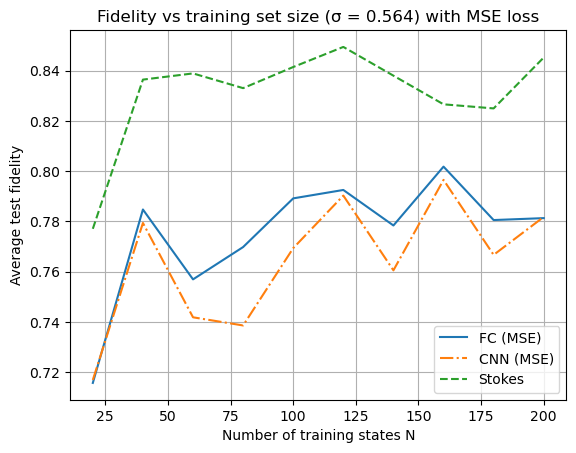

In [ ]:
plt.figure()
plt.plot(N_list, avg_fids_fc_mse,      label='FC (MSE)',  linestyle='-')
plt.plot(N_list, avg_fids_cnn_mse,     label='CNN (MSE)', linestyle='-.')
plt.plot(N_list, avg_fids_stokes_all,  label='Stokes',    linestyle='--')
plt.xlabel("Number of training states N")
plt.ylabel("Average test fidelity")
plt.title(f"Fidelity vs training set size (σ = {sigma}) with MSE loss")
plt.legend()
plt.grid(True)
plt.show()


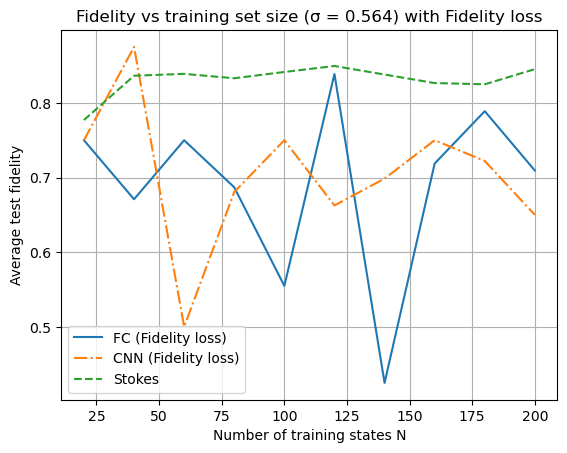

In [ ]:
plt.figure()
plt.plot(N_list, avg_fids_fc_fid,      label='FC (Fidelity loss)',  linestyle='-')
plt.plot(N_list, avg_fids_cnn_fid,     label='CNN (Fidelity loss)', linestyle='-.')
plt.plot(N_list, avg_fids_stokes_all,  label='Stokes',              linestyle='--')
plt.xlabel("Number of training states N")
plt.ylabel("Average test fidelity")
plt.title(f"Fidelity vs training set size (σ = {sigma}) with Fidelity loss")
plt.legend()
plt.grid(True)
plt.show()
